# Praktikum PSD Semester 4

- Nama: Raka Muhammad Al Hafidz
- Kelas: 2C_TNK
- NIM: 241344087

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from scipy.io import wavfile
import requests
from io import BytesIO

#Generate Signal

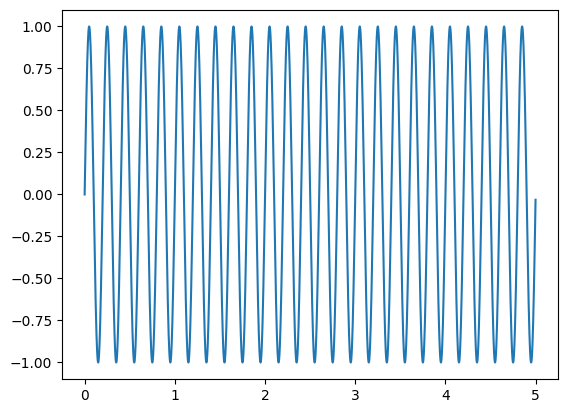

In [ ]:
fs = 1000
f = 5
A = 1
phase = 0
dur = 5

t = np.linspace(0, dur, int(fs * dur), endpoint=False)
signal_sine = A * np.sin(2 * np.pi * f * t + np.deg2rad(phase))

plt.plot(t, signal_sine)

In [19]:
np.save('signal_sinewave.npy', signal_sine)
np.savetxt('signal_sinewave.txt', signal_sine)
data_df = pd.DataFrame(
   {
      'time': t,
      'amplitude': signal_sine
   }
)

data_df.to_csv('signal_sine.csv', index=False)
data_df.to_excel('signal_sine.xlsx')
normalized_signal = np.int16(signal_sine * 32767)
wavfile.write('signal_audio.wav', fs, normalized_signal)

# Load Signal

In [ ]:
#Load .npy file
loaded_signal_sine = np.load('signal_sinewave.npy')

#Load .txt file
loaded_signal_sine_txt = np.loadtxt('signal_sinewave.txt')

#Load .csv file
df_csv_loaded_signal_sine = pd.read_csv('signal_sine.csv')
amplitude_csv_signal = df_csv_loaded_signal_sine['amplitude'].values
time_csv_signal = df_csv_loaded_signal_sine['time'].values

#Load .xlsx file
df_excel_loaded_signal_sine = pd.read_excel('signal_sine.xlsx')
amplitude_excel_signal = df_excel_loaded_signal_sine['amplitude'].values
time_excel_signal = df_excel_loaded_signal_sine['time'].values

#Load audio file
fs_wav, signal_from_wav = wavfile.read('signal_audio.wav')
signal_from_wav = signal_from_wav.astype(np.float32) / 32767

# Mutliple sheet spreadsheet

In [ ]:
fs = 1000
f = 5
A = 1
phase = 0
dur = 1
t = np.linspace(0, dur, int(fs * dur), endpoint=False)
signal_sine = A * np.sin(2 * np.pi * f * t + np.deg2rad(phase))
signal_cosine = A * np.cos(2 * np.pi * f * t + np.deg2rad(phase))

with pd.ExcelWriter('kumpulan_data.xlsx', engine='openpyxl') as writer:
   df_sine = pd.DataFrame({
      'Amplitude' : signal_sine,
      'Time': t,
      'Frequency': f,
      'SampleRate': fs
   })
   df_sine.to_excel(writer, sheet_name='Sine_wave', index=False)

   df_cosine = pd.DataFrame({
      'Amplitude' : signal_cosine,
      'Time': t,
      'Frequency': f,
      'SampleRate': fs
   })
   df_cosine.to_excel(writer, sheet_name='Cosine_wave', index=False)

In [ ]:
## Untuk membaca file dari spreadsheet

#Jika tidak tahu list sheet name yang ada dalam file maka argumen sheet_name=None
df_load_excel = pd.read_excel("kumpulan_data.xlsx",sheet_name=None)
print(df_load_excel.keys()) #untuk cek list

#baru setelah tahu sheet name-nya, di set argumen sheet_name
df_load_sine_wave = pd.read_excel('kumpulan_data.xlsx', sheet_name="Sine_wave")

# Plotting


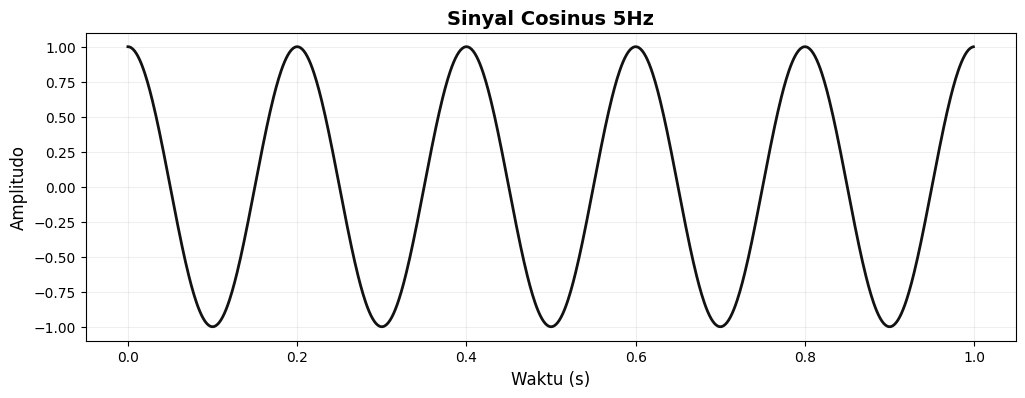

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(t, signal_cosine, linewidth=2, color="#121212")
plt.xlabel("Waktu (s)", fontsize=12)
plt.ylabel("Amplitudo", fontsize=12)
plt.title("Sinyal Cosinus 5Hz", fontsize= 14, fontweight='bold')
plt.grid(True, alpha=0.2)
plt.show()

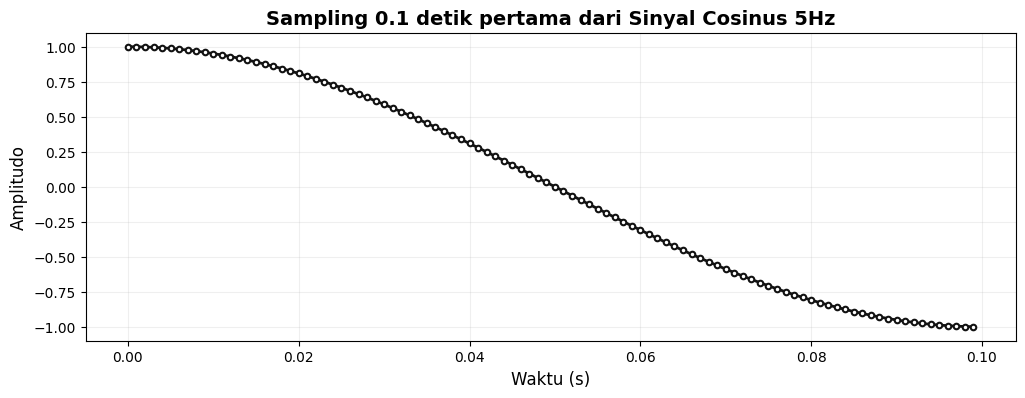

In [16]:
#Display sebagian sin:

plt.figure(figsize=(12,4))
amt_samples_to_plot = 100 #0.1 detik * freq sampling
plt.plot(t[:amt_samples_to_plot], signal_cosine[:amt_samples_to_plot], 'o-', linewidth=2,
         markersize=4, color="#121212", markerfacecolor="#FFFFFF", markeredgewidth=1.5
         )
plt.xlabel("Waktu (s)", fontsize=12)
plt.ylabel("Amplitudo", fontsize=12)
plt.title("Sampling 0.1 detik pertama dari Sinyal Cosinus 5Hz", fontsize= 14, fontweight='bold')
plt.grid(True, alpha=0.2)
plt.show()

# Ploting multiple Channel

(0.0, 1.0)

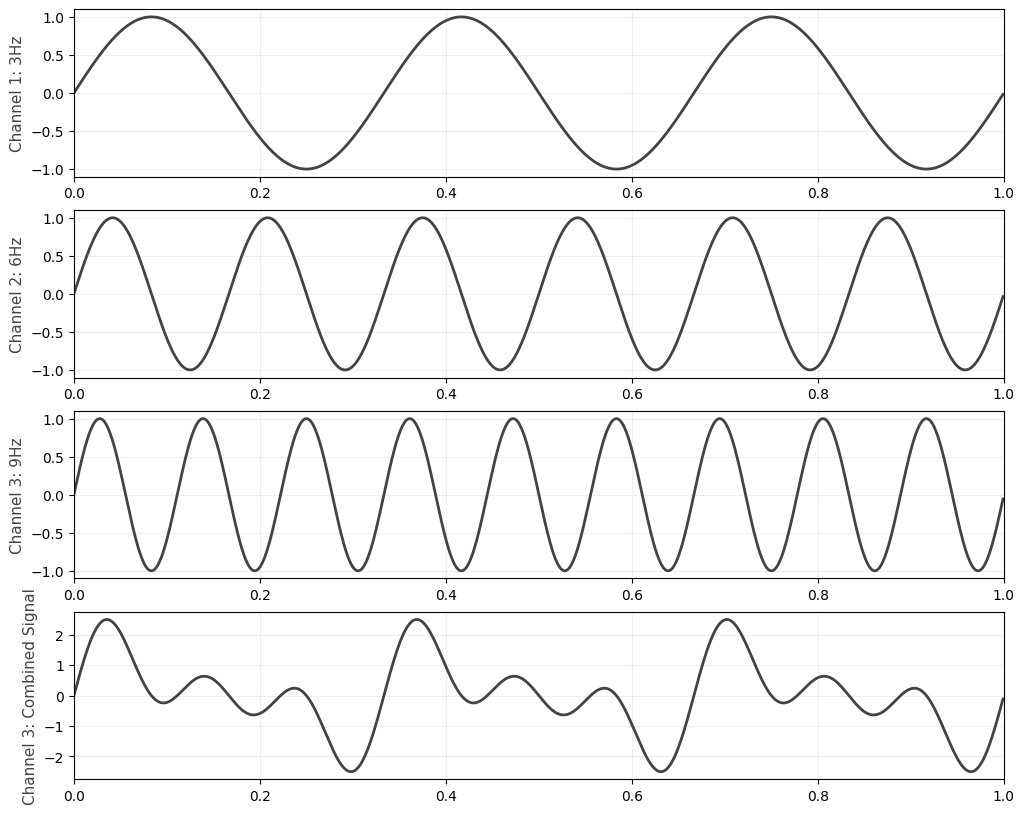

In [ ]:
signal_3Hz = np.sin(2 * np.pi * 3 * t)
signal_6Hz = np.sin(2 * np.pi * 6 * t)
signal_9Hz = np.sin(2 * np.pi * 9 * t)

signal_combined = signal_3Hz + signal_6Hz + signal_9Hz

fig, axes = plt.subplots(4, 1, figsize=(12,10))
# 4 = jumlah jendela []
# 1 = jumlah jendela/channel secara horizontal [][]

axes[0].plot(t, signal_3Hz, linewidth=2, color="#434343")
axes[0].set_ylabel("Channel 1: 3Hz", color="#434343", fontsize=11)
axes[0].grid(True, alpha=0.2)
axes[0].set_xlim([0,1])

axes[1].plot(t, signal_6Hz, linewidth=2, color="#434343")
axes[1].set_ylabel("Channel 2: 6Hz", color="#434343", fontsize=11)
axes[1].grid(True, alpha=0.2)
axes[1].set_xlim([0,1])

axes[2].plot(t, signal_9Hz, linewidth=2, color="#434343")
axes[2].set_ylabel("Channel 3: 9Hz", color="#434343", fontsize=11)
axes[2].grid(True, alpha=0.2)
axes[2].set_xlim([0,1])

axes[3].plot(t, signal_combined, linewidth=2, color="#434343")
axes[3].set_ylabel("Channel 3: Combined Signal", color="#434343", fontsize=11)
axes[3].grid(True, alpha=0.2)
axes[3].set_xlim([0,1])

# Plot Side by Side

(0.0, 1.0)

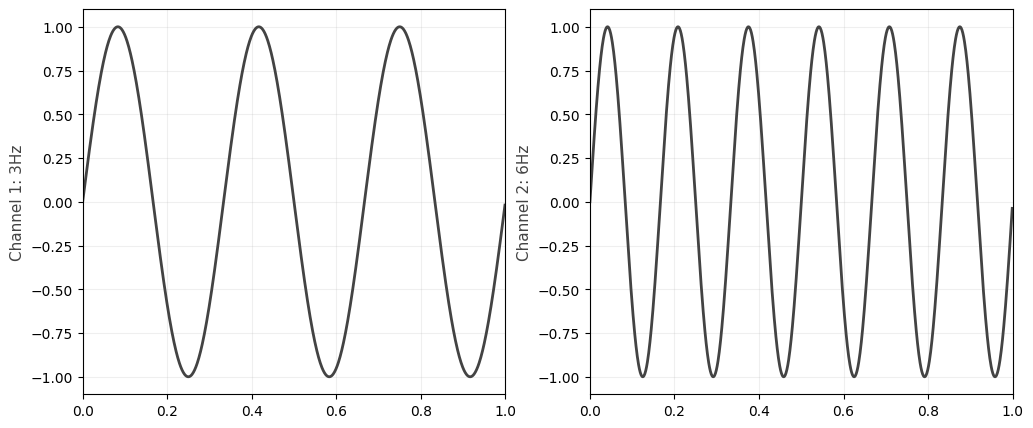

In [23]:
#Side by side:

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].plot(t, signal_3Hz, linewidth=2, color="#434343")
axes[0].set_ylabel("Channel 1: 3Hz", color="#434343", fontsize=11)
axes[0].grid(True, alpha=0.2)
axes[0].set_xlim([0,1])

axes[1].plot(t, signal_6Hz, linewidth=2, color="#434343")
axes[1].set_ylabel("Channel 2: 6Hz", color="#434343", fontsize=11)
axes[1].grid(True, alpha=0.2)
axes[1].set_xlim([0,1])

# Plot 2x2

(0.0, 1.0)

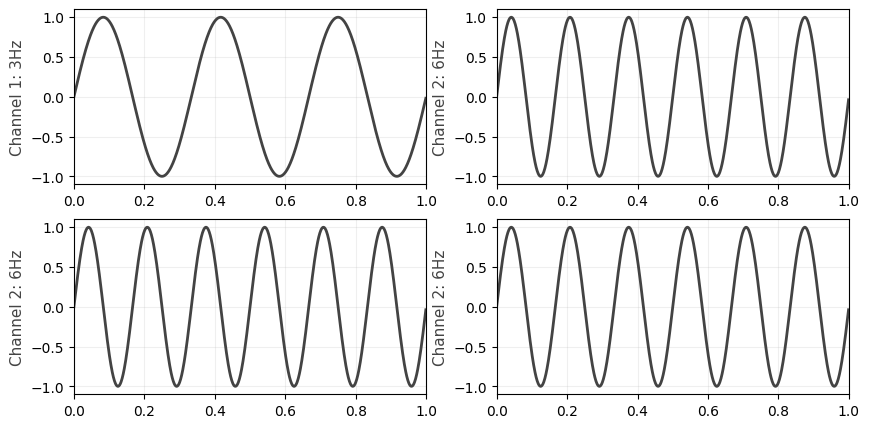

In [ ]:
#Side 4x4:

fig, axes = plt.subplots(2, 2, figsize=(10,5))

#Channel 1 kiri atas
axes[0][0].plot(t, signal_3Hz, linewidth=2, color="#434343")
axes[0][0].set_ylabel("Channel 1: 3Hz", color="#434343", fontsize=11)
axes[0][0].grid(True, alpha=0.2)
axes[0][0].set_xlim([0,1])

#Channel 2
axes[1][0].plot(t, signal_6Hz, linewidth=2, color="#434343")
axes[1][0].set_ylabel("Channel 2: 6Hz", color="#434343", fontsize=11)
axes[1][0].grid(True, alpha=0.2)
axes[1][0].set_xlim([0,1])

#Channel 3
axes[0][1].plot(t, signal_6Hz, linewidth=2, color="#434343")
axes[0][1].set_ylabel("Channel 2: 6Hz", color="#434343", fontsize=11)
axes[0][1].grid(True, alpha=0.2)
axes[0][1].set_xlim([0,1])

#Channel 4
axes[1][1].plot(t, signal_6Hz, linewidth=2, color="#434343")
axes[1][1].set_ylabel("Channel 2: 6Hz", color="#434343", fontsize=11)
axes[1][1].grid(True, alpha=0.2)
axes[1][1].set_xlim([0,1])

### Extract parameter dari sinyal

In [ ]:
def analyze_sampling_parameter(signal, time_vector):
   n_samples = len(signal)
   duration = time_vector[-1] - time_vector[0]
   dt = time_vector[1] - time_vector[0]
   fs = 1/dt

   return{
      'n_samples': n_samples,
      'duration': duration,
      'sampling_interval': dt,
      'sampling_rate': fs
   }


params = analyze_sampling_parameter(signal_3Hz, t)
print("Jumlah n data:  ", params['n_samples'])
print("Durasi sinyal:  ", params['duration'], ' detik')
print("Interval sampling:  ", params['sampling_interval'], ' detik')
print("Frekuensi sampling:  ", params['sampling_rate'], '')

### Tugas

Di google classroom telah diberikan 4 buah file sinyal dengan format .wav.

- 1. Load dan dapatkan sampling parameter dari salah satu sinyal (bebas yang mana), lalu plot sinyal tersebut
- 2. Buat sinyal baru yang merupakan gabungan keempat siyal tersebut.
- 3. Lalu plot 5 sinyal tersebut (4 dari file, 1 gabungan) dalam satu jendela plot.
- 4. Deskripsikan menurut kalian apa / menunjukkan apa sinyal tersebut

In [ ]:
# Load semua mic.wav nya:

fs_mic1wav, mic1_signalwav = wavfile.read('mic1.wav')
mic1_signalwav = mic1_signalwav.astype(np.float32) / 32767

fs_mic2wav, mic2_signalwav = wavfile.read('mic2.wav')
mic2_signalwav = mic2_signalwav.astype(np.float32) / 32767

fs_mic3wav, mic3_signalwav = wavfile.read('mic3.wav')
mic3_signalwav = mic3_signalwav.astype(np.float32) / 32767

fs_mic4wav, mic4_signalwav = wavfile.read('mic4.wav')
mic4_signalwav = mic4_signalwav.astype(np.float32) / 32767


/var/folders/lq/l4sbfyv90lx9h4m4_gq3q4n80000gn/T/ipykernel_33468/2376997938.py:5: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_mic1wav, mic1_signalwav = wavfile.read('mic1.wav')
/var/folders/lq/l4sbfyv90lx9h4m4_gq3q4n80000gn/T/ipykernel_33468/2376997938.py:8: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_mic2wav, mic2_signalwav = wavfile.read('mic2.wav')
/var/folders/lq/l4sbfyv90lx9h4m4_gq3q4n80000gn/T/ipykernel_33468/2376997938.py:11: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_mic3wav, mic3_signalwav = wavfile.read('mic3.wav')
/var/folders/lq/l4sbfyv90lx9h4m4_gq3q4n80000gn/T/ipykernel_33468/2376997938.py:14: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_mic4wav, mic4_signalwav = wavfile.read('mic4.wav')


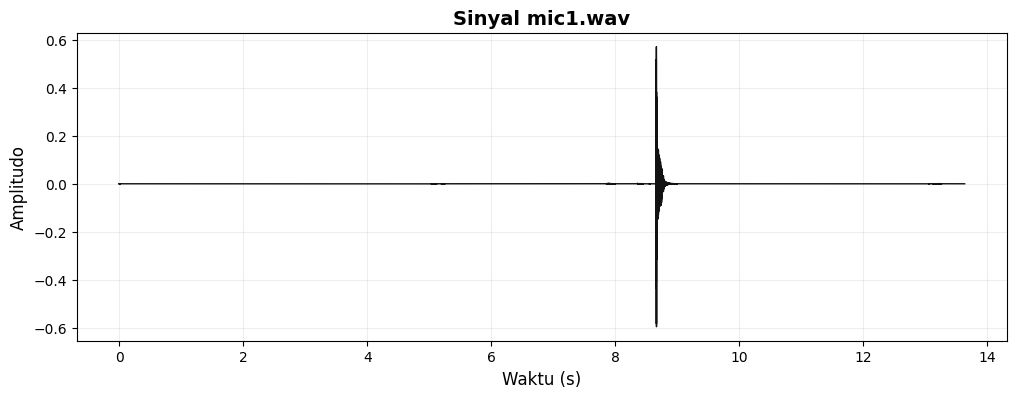

In [ ]:
# Plot salah satu sinyal:

dur_wav = len(mic1_signalwav) / fs_mic1wav
t_wav = np.linspace(0, dur_wav, int(fs_mic1wav * dur_wav), endpoint=False)

plt.figure(figsize=(12,4))
plt.plot(t_wav, mic1_signalwav, linewidth=1, color="#121212")
plt.xlabel("Waktu (s)", fontsize=12)
plt.ylabel("Amplitudo", fontsize=12)
plt.title("Sinyal mic1.wav", fontsize= 14, fontweight='bold')
plt.grid(True, alpha=0.2)
plt.show()

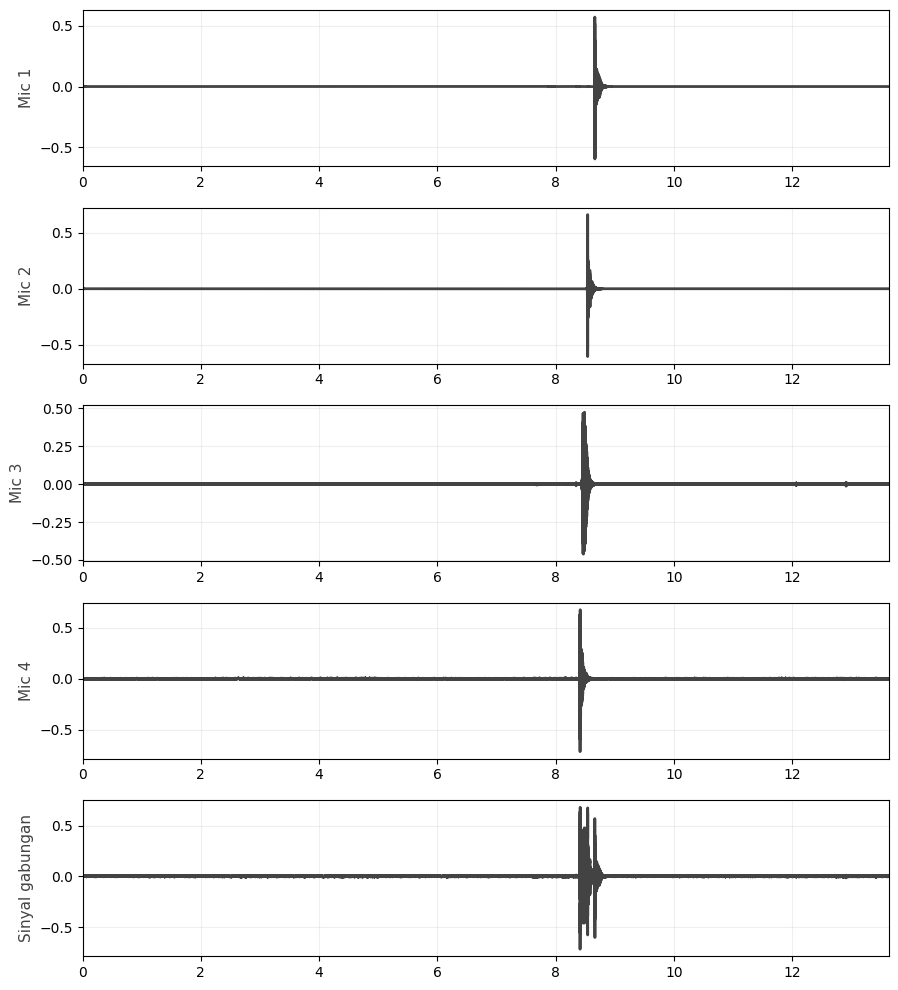

In [30]:
#Sinyal baru, gabungan dari ke-4 tersebut:

signal_gabungan = mic1_signalwav + mic2_signalwav + mic3_signalwav + mic4_signalwav


fig, axes = plt.subplots(5, 1, figsize=(9,10))


ax1 = axes[0]
ax2 = axes[1]
ax3 = axes[2]
ax4 = axes[3]
ax5 = axes[4]

# Plot Mic 1
ax1.plot(t_wav, mic1_signalwav, linewidth=2, color="#434343")
ax1.set_ylabel("Mic 1", color="#434343", fontsize=11)
ax1.grid(True, alpha=0.2)
ax1.set_xlim([0, dur_wav])

# Plot Mic 2
ax2.plot(t_wav, mic2_signalwav, linewidth=2, color="#434343")
ax2.set_ylabel("Mic 2", color="#434343", fontsize=11)
ax2.grid(True, alpha=0.2)
ax2.set_xlim([0, dur_wav])

# Plot Mic 3
ax3.plot(t_wav, mic3_signalwav, linewidth=2, color="#434343")
ax3.set_ylabel("Mic 3", color="#434343", fontsize=11)
ax3.grid(True, alpha=0.2)
ax3.set_xlim([0, dur_wav])

# Plot Mic 4
ax4.plot(t_wav, mic4_signalwav, linewidth=2, color="#434343")
ax4.set_ylabel("Mic 4", color="#434343", fontsize=11)
ax4.grid(True, alpha=0.2)
ax4.set_xlim([0, dur_wav])

# Plot Sinyal gabungan
ax5.plot(t_wav, signal_gabungan, linewidth=2, color="#434343")
ax5.set_ylabel("Sinyal gabungan", color="#434343", fontsize=11)
ax5.grid(True, alpha=0.2)
ax5.set_xlim([0, dur_wav])

plt.tight_layout()
plt.show()

### Deskripsikan

Sinyal tersebut adalah sebuah sinyal yang diploting dari audio, masing-masing berdurasi sekitar 13.6 detik (tidak exact, tapi kira kira segitu).

Jika di-play, ke-4 file audio tersebut menunjukkan suara yang identik, suara hening pada awal (dengan sedikit noise), dan suara keras seperti hentakkan rotan yang tiba tiba ada pada detik ke-8. Suara hentakkan keras tersebut mengakibatkan lonjakan amplitudo yang tiba tiba yang terjadi pada sinyal/audio tersebut. Bisa dilihat pada gambar bahwa lonjakkan yang dimaksud ada di sana.

Karakteristik sinyal gabungan terlihat sedikit lebih "tebal" pada area lonjakan. Hal terjadi dikarenakan perbedaan waktu tiba suara (delay) yang sangat kecil antar mikrofon dapat membuat durasi lonjakan terlihat sedikit melebar. (bisa dilihat bahwa lonjakan di tiap grafik tidak simetris dengan sinyal yang lain)